Import Libraries

In [1]:
# AML Algorithm 2.1 - Gaussian Process Regression
# Rasmussen & Williams implementation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.style.use("seaborn-v0_8")

Create Folders for Data and Plots

In [2]:
os.makedirs("data", exist_ok=True)
os.makedirs("plots", exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


Creating Regression Dataset : Standard GP Dataset

y=sin(x)+noise

In [3]:
np.random.seed(42)

X_train = np.linspace(0, 10, 20).reshape(-1,1)

y_train = np.sin(X_train) + 0.3*np.random.randn(20,1)

dataset = pd.DataFrame({
    "X": X_train.flatten(),
    "y": y_train.flatten()
})

dataset_path = "data/AML_algo2_1_regression_dataset.csv"
dataset.to_csv(dataset_path, index=False)

print("Dataset saved at:", dataset_path)

dataset.head()

Dataset saved at: data/AML_algo2_1_regression_dataset.csv


,X,y
0,0.000000,0.149014
1,0.526316,0.460872
2,1.052632,1.063036
3,1.578947,1.456876
4,2.105263,0.790294


Visualize Training Data

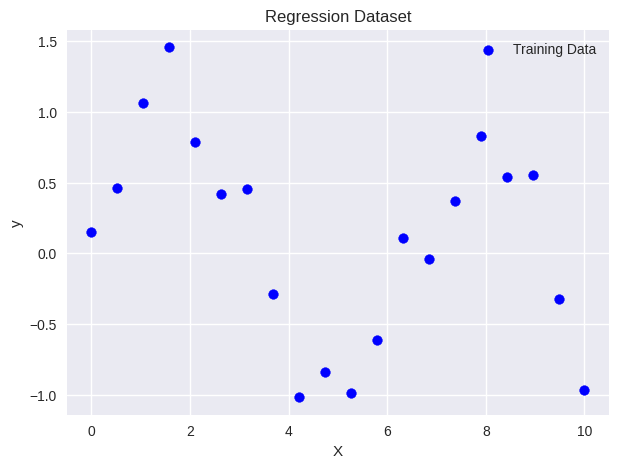

In [4]:
plt.figure(figsize=(7,5))
plt.scatter(X_train, y_train, color='blue', label="Training Data")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Regression Dataset")
plt.legend()

plt.show()

Implement the RBF Kernel

In [5]:
def rbf_kernel(X1, X2, length_scale=1.0, sigma_f=1.0):

    sqdist = np.sum(X1**2,1).reshape(-1,1) + np.sum(X2**2,1) - 2*np.dot(X1, X2.T)

    return sigma_f**2 * np.exp(-0.5 / length_scale**2 * sqdist)

Compute Training Covariance Matrix

In [6]:
length_scale = 1.0
sigma_f = 1.0
sigma_n = 0.3

K = rbf_kernel(X_train, X_train, length_scale, sigma_f)

K += sigma_n**2 * np.eye(len(X_train))

print("Covariance matrix shape:", K.shape)

Covariance matrix shape: (20, 20)


Cholesky Decomposition

In [7]:
L = np.linalg.cholesky(K)

print("Cholesky matrix shape:", L.shape)

Cholesky matrix shape: (20, 20)


Compute α

In [8]:
alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train))

print("Alpha shape:", alpha.shape)

Alpha shape: (20, 1)


Create Test Inputs

In [9]:
X_test = np.linspace(0, 10, 100).reshape(-1,1)

Computing Covariance Between Training and Test Data

In [10]:
K_star = rbf_kernel(X_train, X_test, length_scale, sigma_f)

Predictive Mean

In [11]:
f_mean = K_star.T @ alpha

Compute Intermediate Variable v

In [12]:
v = np.linalg.solve(L, K_star)

Predictive Variance

In [13]:
K_star_star = rbf_kernel(X_test, X_test, length_scale, sigma_f)

f_var = np.diag(K_star_star) - np.sum(v**2, axis=0)

f_std = np.sqrt(f_var)

Plot Gaussian Process Regression

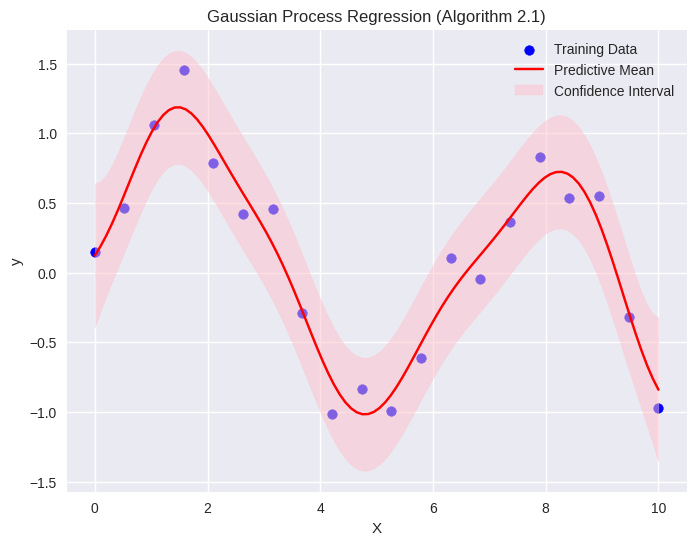

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(X_train, y_train, color='blue', label='Training Data')

plt.plot(X_test, f_mean, color='red', label='Predictive Mean')

plt.fill_between(
    X_test.flatten(),
    f_mean.flatten() - 2*f_std,
    f_mean.flatten() + 2*f_std,
    color='pink',
    alpha=0.5,
    label='Confidence Interval'
)

plt.title("Gaussian Process Regression (Algorithm 2.1)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()

plt.show()

Save the Plot

Plot saved at: plots/AML_algo2_1_gp_prediction.png


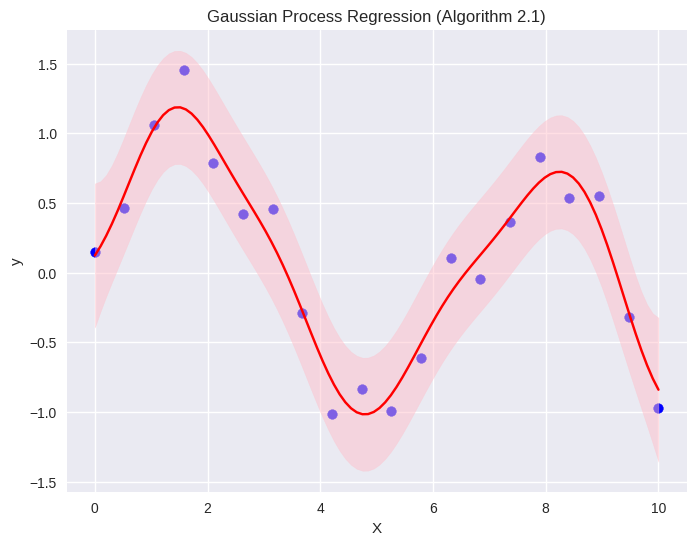

In [15]:
plot_path = "plots/AML_algo2_1_gp_prediction.png"
plt.figure(figsize=(8,6))

plt.scatter(X_train, y_train, color='blue')
plt.plot(X_test, f_mean, color='red')

plt.fill_between(
    X_test.flatten(),
    f_mean.flatten() - 2*f_std,
    f_mean.flatten() + 2*f_std,
    color='pink',
    alpha=0.5
)

plt.title("Gaussian Process Regression (Algorithm 2.1)")
plt.xlabel("X")
plt.ylabel("y")

plt.savefig(plot_path)
print("Plot saved at:", plot_path)

Creating Toy 2D Dataset

In [16]:
X_train_2D = np.array([
    [1,2],
    [2,3],
    [3,1],
    [4,2],
    [5,3]
])

y_train_2D = np.array([3,4,2,5,4]).reshape(-1,1)


toy_dataset = pd.DataFrame({
    "x1": X_train_2D[:,0],
    "x2": X_train_2D[:,1],
    "y": y_train_2D.flatten()
})

toy_path = "data/AML_algo2_1_toy2D_dataset.csv"
toy_dataset.to_csv(toy_path, index=False)

print("Toy dataset saved at:", toy_path)

toy_dataset

Toy dataset saved at: data/AML_algo2_1_toy2D_dataset.csv


,x1,x2,y
0,1,2,3
1,2,3,4
2,3,1,2
3,4,2,5
4,5,3,4


Define a 2D Test Input

In [17]:
X_test_2D = np.array([[2.5,2]])

print("Test point:", X_test_2D)

Test point: [[2.5 2. ]]


Compute Covariance Between Training Points

In [18]:
K_2D = rbf_kernel(X_train_2D, X_train_2D, length_scale=1.0, sigma_f=1.0)

print("Covariance matrix:\n", K_2D)

Covariance matrix:
 [[1.00000000e+00 3.67879441e-01 8.20849986e-02 1.11089965e-02
  2.03468369e-04]
 [3.67879441e-01 1.00000000e+00 8.20849986e-02 8.20849986e-02
  1.11089965e-02]
 [8.20849986e-02 8.20849986e-02 1.00000000e+00 3.67879441e-01
  1.83156389e-02]
 [1.11089965e-02 8.20849986e-02 3.67879441e-01 1.00000000e+00
  3.67879441e-01]
 [2.03468369e-04 1.11089965e-02 1.83156389e-02 3.67879441e-01
  1.00000000e+00]]


Compute Covariance Between Training and Test Input

In [19]:
K_star_2D = rbf_kernel(X_train_2D, X_test_2D)

print("Covariance with test point:\n", K_star_2D)

Covariance with test point:
 [[0.32465247]
 [0.53526143]
 [0.53526143]
 [0.32465247]
 [0.0266491 ]]


Plot Covariance Heatmap

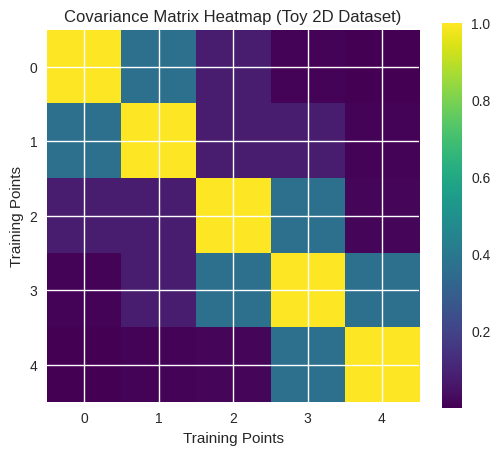

In [20]:
plt.figure(figsize=(6,5))

plt.imshow(K_2D, cmap='viridis')
plt.colorbar()

plt.title("Covariance Matrix Heatmap (Toy 2D Dataset)")
plt.xlabel("Training Points")
plt.ylabel("Training Points")

plt.show()

Save Heatmap Plot

Heatmap saved at: plots/AML_algo2_1_covariance_heatmap.png


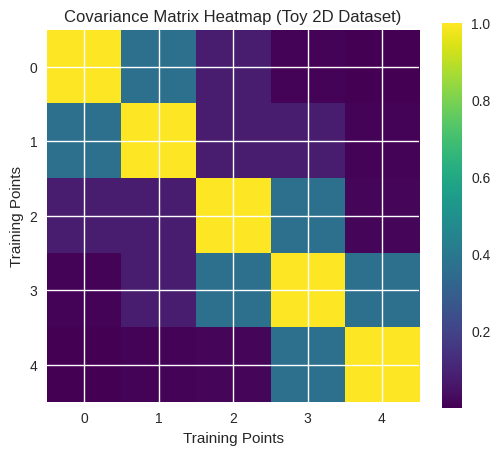

In [21]:
heatmap_path = "plots/AML_algo2_1_covariance_heatmap.png"

plt.figure(figsize=(6,5))

plt.imshow(K_2D, cmap='viridis')
plt.colorbar()

plt.title("Covariance Matrix Heatmap (Toy 2D Dataset)")
plt.xlabel("Training Points")
plt.ylabel("Training Points")

plt.savefig(heatmap_path)

print("Heatmap saved at:", heatmap_path)